In [1]:
%pip install -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [2]:
import sys
import os

path = os.path.expanduser('~/Documenti/Tesi-Magistrale/data')
os.chdir(path)
# Aggiunge la directory corrente al PATH per trovare 'src'
if os.getcwd() not in sys.path:
    sys.path.append(os.getcwd())

print(f"Directory attuale: {os.getcwd()}")

Directory attuale: /home/andy/Documenti/Tesi-Magistrale/data


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import time
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit
from tqdm import tqdm
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, accuracy_score, recall_score, f1_score, precision_score
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv('dataset_immagini.csv')
df

,dicom_id,path_image,subject_id,anchor_time,target
0,0009a9fb-eb905e90-824cad7c-16d40468-007f0038,MIMIC_SUPER_RES_24K/0009a9fb-eb905e90-824cad7c...,10001401,2131-06-11 06:50:00,0
1,000fe830-f18703f9-765fd2d6-eb316278-1bd6e8d2,MIMIC_SUPER_RES_24K/000fe830-f18703f9-765fd2d6...,16141152,2197-09-16 06:45:00,0
2,00126448-9dfa1383-58c9cb80-9b78c170-5ca8bf1c,MIMIC_SUPER_RES_24K/00126448-9dfa1383-58c9cb80...,18455225,2171-05-24 06:43:00,0
3,0013b91b-c4487243-1bacad43-6a4c135c-d4379557,MIMIC_SUPER_RES_24K/0013b91b-c4487243-1bacad43...,18362456,2138-04-02 08:25:00,0
4,00144baa-cb60c49c-5290493f-c93ac4a1-31db7ba5,MIMIC_SUPER_RES_24K/00144baa-cb60c49c-5290493f...,19673150,2166-05-05 13:00:00,0
...,...,...,...,...,...
16241,ffe46d4f-d2538f9c-fea906a4-3e615381-98237d83,MIMIC_SUPER_RES_24K/ffe46d4f-d2538f9c-fea906a4...,19640899,2187-07-15 20:15:00,0
16242,ffebfbb9-578f0675-00d0a0c2-494c5bc6-cd9ca407,MIMIC_SUPER_RES_24K/ffebfbb9-578f0675-00d0a0c2...,19625397,2182-08-13 04:47:00,0
16243,ffecd6b4-9c8fc902-598013ee-90d09c4e-a3341b4d,MIMIC_SUPER_RES_24K/ffecd6b4-9c8fc902-598013ee...,14849354,2178-12-04 05:20:00,0
16244,ffede0ba-5b5d8b13-a4c6b4d5-097504d5-e427c37f,MIMIC_SUPER_RES_24K/ffede0ba-5b5d8b13-a4c6b4d5...,19611909,2160-11-22 04:41:00,0


In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo in uso: {device}")

Dispositivo in uso: cuda


In [6]:
gss = GroupShuffleSplit(n_splits=1, train_size=0.7, random_state=42)
train_idx, temp_idx = next(gss.split(df, groups=df['subject_id']))
train_df_raw = df.iloc[train_idx].copy()
temp_df = df.iloc[temp_idx].copy()

gss_val = GroupShuffleSplit(n_splits=1, train_size=0.66, random_state=42)
val_idx, test_idx = next(gss_val.split(temp_df, groups=temp_df['subject_id']))
val_df = temp_df.iloc[val_idx].copy()
test_df = temp_df.iloc[test_idx].copy()

train_positi = train_df_raw[train_df_raw['target'] == 1]


n_negativi = 2000
train_negativi = train_df_raw[train_df_raw['target'] == 0].sample(n=n_negativi, random_state=42)

train_df = pd.concat([train_positi, train_negativi]).sample(frac=1, random_state=42).reset_index(drop=True)

# --- VERIFICA FINALE ---
print("--- Riepilogo Dataset Post-Bilanciamento ---")
print(f"Train (Bilanciato): {len(train_df)} immagini | Masse: {train_df['target'].sum()}")
print(f"Val (Originale):   {len(val_df)} immagini | Masse: {val_df['target'].sum()}")
print(f"Test (Originale):  {len(test_df)} immagini | Masse: {test_df['target'].sum()}")

--- Riepilogo Dataset Post-Bilanciamento ---
Train (Bilanciato): 2027 immagini | Masse: 27
Val (Originale):   3197 immagini | Masse: 4
Test (Originale):  1641 immagini | Masse: 2


In [7]:
class MimicDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True) # Reset fondamentale dopo lo split
        self.transform = transform

    def __len__(self): 
        return len(self.df)

    def __getitem__(self, idx):
        # Prendiamo il path direttamente dalla colonna del DataFrame
        # Se il path nel CSV è "MIMIC_SUPER_RES_24K/0009a9fb...", lo usiamo così
        full_path = self.df.iloc[idx]['path_image']
        
        # Aggiungiamo l'estensione se manca (controlla se i tuoi file sono .png o .jpg)
        if not full_path.lower().endswith(('.png', '.jpg', '.jpeg')):
            full_path += ".png" 
        
        try:
            # Carichiamo in scala di grigi L (8-bit pixels, black and white)
            # Poi convertiamo in RGB per compatibilità con ResNet (3 canali identici)
            image = Image.open(full_path).convert('RGB')
        except FileNotFoundError:
            # Fallback se il path nel CSV ha una cartella di troppo o diversa
            img_name = os.path.basename(full_path)
            image = Image.open(os.path.join("MIMIC_SUPER_RES_24K", img_name)).convert('RGB')
        
        label = torch.tensor(self.df.iloc[idx]['target'], dtype=torch.float32)
        
        if self.transform: 
            image = self.transform(image)
            
        return image, label

In [8]:
# Augmentation per il Training
train_trans = transforms.Compose([
    transforms.RandomRotation(30),
    transforms.RandomHorizontalFlip(),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)), # Zoom sulle masse!
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Trasformazione per Validation e Test (No Augmentation)
test_trans = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

In [9]:
target_list = train_df['target'].values
class_sample_count = np.array([len(np.where(target_list == t)[0]) for t in np.unique(target_list)])
weight = 1. / class_sample_count
samples_weights = torch.from_numpy(weight[target_list.astype(int)])
sampler = WeightedRandomSampler(samples_weights, len(samples_weights))

BATCH_SIZE = 32  # Alziamo a 32 per saturare meglio la VRAM della 5060
NUM_WORKERS = 4   # Usa 4 core per il caricamento parallelo delle immagini
PIN_MEMORY = True # Accelera il trasferimento dei dati alla GPU

# 1. TRAIN LOADER (Con Sampler per bilanciare le 33 masse)
train_loader = DataLoader(
    MimicDataset(train_df, transform=train_trans), 
    batch_size=BATCH_SIZE, 
    sampler=sampler, 
    num_workers=NUM_WORKERS, 
    pin_memory=PIN_MEMORY,
    prefetch_factor=2 # Pre-carica i batch successivi
)

# 2. VALIDATION LOADER (Per monitorare l'epoca in corso)
val_loader = DataLoader(
    MimicDataset(val_df, transform=test_trans), 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=PIN_MEMORY
)

# 3. TEST LOADER (Per la valutazione finale e matrici di confusione)
test_loader = DataLoader(
    MimicDataset(test_df, transform=test_trans), 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    num_workers=NUM_WORKERS, 
    pin_memory=PIN_MEMORY
)

In [10]:
model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Congeliamo tutto inizialmente
for param in model.parameters():
    param.requires_grad = False

# Sblocchiamo il Layer 4 (fondamentale per estrarre feature complesse come le masse)
for param in model.layer4.parameters():
    param.requires_grad = True

# Nuova testa di classificazione (con Dropout per ridurre l'overfitting)
model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 1)
)
model = model.to(device)

# 2. FOCAL LOSS PESATA (Il cuore della soluzione)
class WeightedFocalLoss(nn.Module):
    def __init__(self, alpha=0.8, gamma=2):
        super(WeightedFocalLoss, self).__init__()
        self.alpha = alpha  # Peso per la classe positiva
        self.gamma = gamma  # Fattore di focalizzazione

    def forward(self, inputs, targets):
        # Usiamo binary_cross_entropy_with_logits per stabilità numerica
        BCE_loss = nn.functional.binary_cross_entropy_with_logits(inputs, targets, reduction='none')
        pt = torch.exp(-BCE_loss)
        
        # Applichiamo il peso alpha solo ai positivi (targets == 1)
        # Questo forza il modello a dare importanza alle 33 masse
        weights = targets * self.alpha + (1 - targets) * (1 - self.alpha)
        
        focal_loss = weights * (1 - pt)**self.gamma * BCE_loss
        return focal_loss.mean()

# Inizializziamo con alpha alto (0.8+) per "urlare" al modello di guardare le masse
criterion = WeightedFocalLoss(alpha=0.9, gamma=2)

# 3. OTTIMIZZATORE: Solo per i parametri sbloccati
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

In [11]:
# --- CONFIGURAZIONE SOGLIA ---
THRESHOLD = 0.5

history = {
    'train_loss': [], 'val_loss': [],
    'train_acc': [], 'val_acc': [],
    'train_recall': [], 'val_recall': []
}

epochs = 5

print(f"Training avviato su: {device}")
print(f"Soglia decisionale impostata a: {THRESHOLD} (per massimizzare la Recall)")
print("-" * 50)

for epoch in range(epochs):
    start_time = time.time()
    
    # --- FASE DI TRAINING ---
    model.train()
    t_loss = 0
    t_preds, t_targets = [], []
    
    train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [TRAIN]")
    
    for imgs, lbls in train_pbar:
        imgs, lbls = imgs.to(device), lbls.to(device).view(-1, 1)
        
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, lbls)
        loss.backward()
        optimizer.step()
        
        t_loss += loss.item()
        
        # Applichiamo la soglia THRESHOLD per le predizioni
        probs = torch.sigmoid(outputs)
        preds = (probs > THRESHOLD).float().detach().cpu().numpy()
        
        t_preds.extend(preds)
        t_targets.extend(lbls.detach().cpu().numpy())
        
        train_pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    train_loss_avg = t_loss / len(train_loader)
    train_rec = recall_score(t_targets, t_preds, zero_division=0)
    train_acc = accuracy_score(t_targets, t_preds)
    
    # --- FASE DI VALIDAZIONE ---
    model.eval()
    v_loss = 0
    v_preds, v_targets = [], []
    
    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [VAL]", leave=False)
    
    with torch.no_grad():
        for imgs, lbls in val_pbar:
            imgs, lbls = imgs.to(device), lbls.to(device).view(-1, 1)
            outputs = model(imgs)
            
            v_loss += criterion(outputs, lbls).item()
            
            probs_v = torch.sigmoid(outputs)
            # Applichiamo la stessa soglia THRESHOLD in validazione
            preds_v = (probs_v > THRESHOLD).float().cpu().numpy()
            
            v_preds.extend(preds_v)
            v_targets.extend(lbls.cpu().numpy())
            
    val_loss_avg = v_loss / len(val_loader)
    val_rec = recall_score(v_targets, v_preds, zero_division=0)
    val_acc = accuracy_score(v_targets, v_preds)
    
    # Salvataggio History
    history['train_loss'].append(train_loss_avg)
    history['val_loss'].append(val_loss_avg)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['train_recall'].append(train_rec)
    history['val_recall'].append(val_rec)
    
    epoch_duration = time.time() - start_time
    
    print(f"Epoch {epoch+1} completata in {epoch_duration:.0f}s")
    print(f"   [TRAIN] Loss: {train_loss_avg:.4f} | Recall: {train_rec:.4f} | Acc: {train_acc:.4f}")
    print(f"   [VAL]   Loss: {val_loss_avg:.4f} | Recall: {val_rec:.4f} | Acc: {val_acc:.4f}")
    print("-" * 50)

# --- SALVATAGGIO FINALE ---
torch.save(model.state_dict(), "resnet_best_5060_balanced.pt")
with open("training_history_balanced.json", 'w') as f:
    json.dump(history, f)

print("\nTraining completato con successo!")

Training avviato su: cuda
Soglia decisionale impostata a: 0.5 (per massimizzare la Recall)
--------------------------------------------------


Epoch 1/5 [TRAIN]: 100%|██████████| 64/64 [01:01<00:00,  1.03it/s, loss=0.0338]


Epoch 1 completata in 130s
   [TRAIN] Loss: 0.0416 | Recall: 0.9713 | Acc: 0.5150
   [VAL]   Loss: 0.0449 | Recall: 1.0000 | Acc: 0.0066
--------------------------------------------------


Epoch 2/5 [TRAIN]: 100%|██████████| 64/64 [01:03<00:00,  1.01it/s, loss=0.0231]


Epoch 2 completata in 131s
   [TRAIN] Loss: 0.0203 | Recall: 0.9990 | Acc: 0.6330
   [VAL]   Loss: 0.0151 | Recall: 0.5000 | Acc: 0.7573
--------------------------------------------------


...

Epoch 3 completata in 131s
   [TRAIN] Loss: 0.0089 | Recall: 0.9980 | Acc: 0.9043
   [VAL]   Loss: 0.0029 | Recall: 0.2500 | Acc: 0.9803
--------------------------------------------------


Epoch 4/5 [TRAIN]: 100%|██████████| 64/64 [01:04<00:00,  1.00s/it, loss=0.0051]


Epoch 4 completata in 130s
   [TRAIN] Loss: 0.0051 | Recall: 0.9971 | Acc: 0.9640
   [VAL]   Loss: 0.0050 | Recall: 0.2500 | Acc: 0.9315
--------------------------------------------------


Epoch 5/5 [TRAIN]: 100%|██████████| 64/64 [01:01<00:00,  1.04it/s, loss=0.0005]


Epoch 5 completata in 130s
   [TRAIN] Loss: 0.0033 | Recall: 0.9980 | Acc: 0.9758
   [VAL]   Loss: 0.0031 | Recall: 0.0000 | Acc: 0.9684
--------------------------------------------------

Training completato con successo!


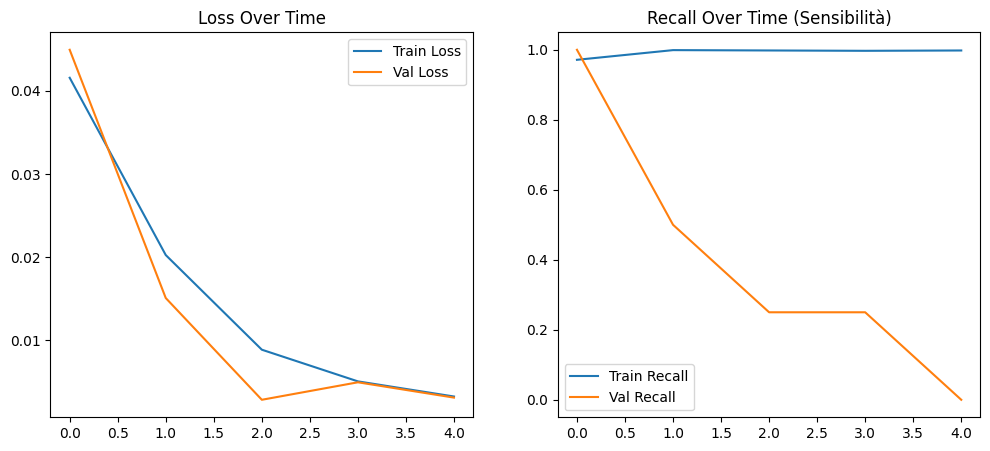

In [12]:
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Over Time')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_recall'], label='Train Recall')
plt.plot(history['val_recall'], label='Val Recall')
plt.title('Recall Over Time (Sensibilità)')
plt.legend()
plt.show()